In [13]:
import os

import matplotlib.pyplot as plt
import optuna

storage = os.environ["OPTUNA_STORAGE"]
datasets = [
    "cifar100",
    "core50",
    "imagenetr",
]
methods = [
    # "linear",
    # "lora",
    "ball",
    # "replay",
    # "gdumb",
    # "der",
    # "joint",
    # "rwalk",
    # "l2p",
    # "ewc",
    "tball",
    "rball",
    # "rtball",
]
study_names = set(optuna.get_all_study_names(storage=storage))

studies = {}
for dataset in datasets:
    studies[dataset] = {}
    for method in methods:
        study_name = f"bayescl/hp/{dataset}/{method}"
        if study_name not in study_names:
            continue

        df = optuna.load_study(
            study_name=study_name, storage=storage
        ).trials_dataframe()
        df = df[df["state"] == "COMPLETE"]
        if df.empty:
            continue

        studies[dataset][method] = df
_MARKERS = ["o", "^", "s", "D"]
COLORS = {method: i for i, method in enumerate(methods)}
MARKER = {method: _MARKERS[i % len(_MARKERS)] for i, method in enumerate(methods)}
CMAP = plt.get_cmap("tab20b")

In [14]:
for dataset, ds_studies in studies.items():
    for method, study in ds_studies.items():
        print(f"{dataset:<10} {method:<10} {len(study)}")

cifar100   ball       15
cifar100   tball      15
cifar100   rball      1
core50     ball       14
core50     tball      11
imagenetr  ball       14
imagenetr  tball      1


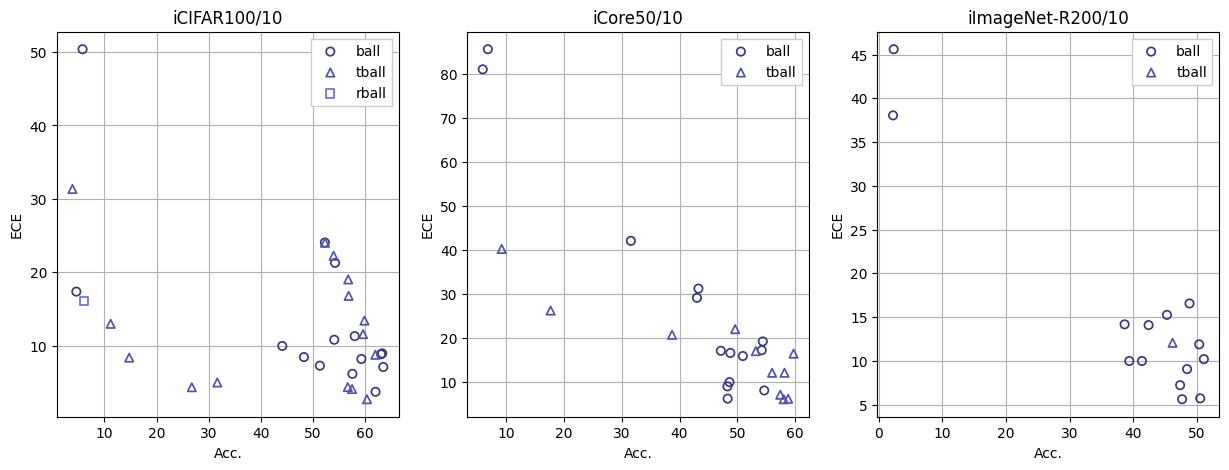

In [15]:
from typing import Dict

import pandas as pd
from matplotlib.axes import Axes


def plot_trials(ax: Axes, trials: Dict[str, pd.DataFrame]):
    ax.grid(True)
    ax.set_axisbelow(True)
    for method, df in trials.items():
        color = CMAP(COLORS[method] % CMAP.N)
        x = df["values_0"] * 100
        y = df["values_1"] * 100
        ax.scatter(
            x,
            y,
            label=method,
            color=color,
            marker=MARKER[method],
            facecolors="none",
            lw=1.25,
        )
    ax.set_ylabel("ECE")
    ax.set_xlabel("Acc.")

    # ax.set_ylim(0, 10)

    # aspect ratio 1:1
    # ax.set_aspect("equal", adjustable="datalim")
    # ax.axis("square")


fig, (ax_cifar100, ax_core50, ax_imagenetr) = plt.subplots(1, 3, figsize=(15, 5))

plot_trials(ax_cifar100, studies["cifar100"])
plot_trials(ax_core50, studies["core50"])
plot_trials(ax_imagenetr, studies["imagenetr"])

ax_cifar100.set_title("iCIFAR100/10")
ax_core50.set_title("iCore50/10")
ax_imagenetr.set_title("iImageNet-R200/10")

ax_cifar100.legend(frameon=True, framealpha=1, fancybox=False)
ax_core50.legend(frameon=True, framealpha=1, fancybox=False)
ax_imagenetr.legend(frameon=True, framealpha=1, fancybox=False)

In [16]:
import tabulate

for dataset, ds_studies in studies.items():
    table = []
    for method, df in ds_studies.items():
        df_acc = df["values_0"] * 100
        df_ece = df["values_1"] * 100
        df_score = (df_acc + (100 - df_ece)) / 2
        best_idx = df_score.idxmax()
        best_trial = df.loc[best_idx]

        acc = f"{best_trial['values_0'] * 100:.2f}"
        ece = f"{best_trial['values_1'] * 100:.2f}"
        score = f"{df_score[best_idx]:.2f}"
        count = len(df)
        table.append((method, acc, ece, score, count))

    print(
        tabulate.tabulate(
            table,
            headers=[f"{dataset} Method", "Acc.", "ECE", "Score", "Count"],
            tablefmt="tsv",
        )
    )
    print()

cifar100 Method  	  Acc.	  ECE	  Score	  Count
ball             	 61.98	 3.72	  79.13	     15
tball            	 60.35	 2.71	  78.82	     15
rball            	  6.14	16.07	  45.03	      1

core50 Method  	  Acc.	  ECE	  Score	  Count
ball           	 54.63	 8.04	  73.3 	     14
tball          	 58.76	 6.14	  76.31	     11

imagenetr Method  	  Acc.	  ECE	  Score	  Count
ball              	 50.55	 5.73	  72.41	     14
tball             	 46.2 	12.07	  67.06	      1



(0.0, 2.0)

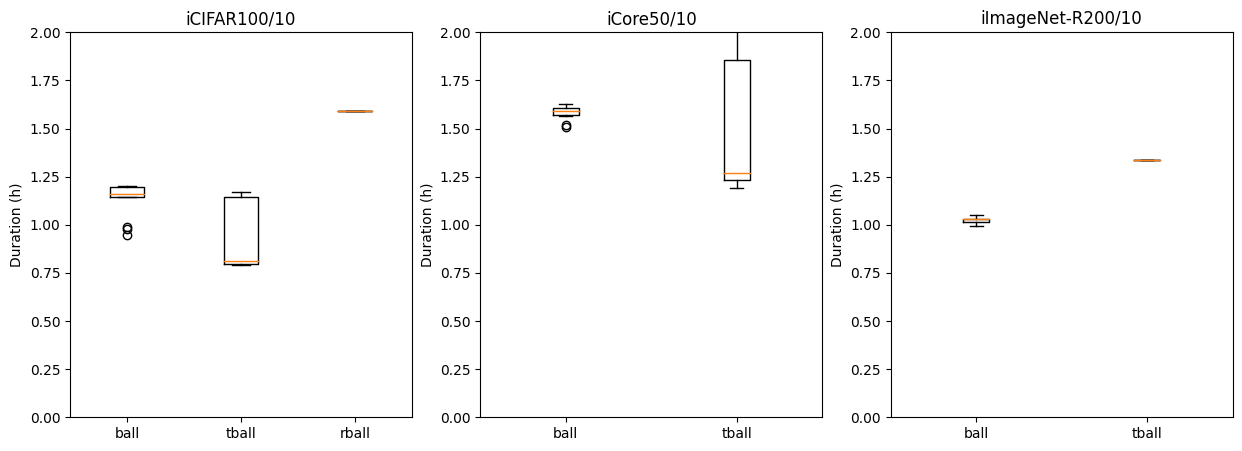

In [17]:
import numpy as np


def boxplot_durations(ax: Axes, trials: Dict[str, pd.DataFrame]):
    # ns to hours
    scale = np.timedelta64(1, "h")
    durations = {}
    for method, df in trials.items():
        durations[method] = df["duration"].dropna() / scale

    ax.boxplot(durations.values(), labels=durations.keys())
    ax.set_ylabel("Duration (h)")
    ax.set_title("Training Duration")


fig, (ax_duration_cifar100, ax_duration_core50, ax_duration_imagenetr) = plt.subplots(
    1, 3, figsize=(15, 5)
)

boxplot_durations(ax_duration_cifar100, studies["cifar100"])
boxplot_durations(ax_duration_core50, studies["core50"])
boxplot_durations(ax_duration_imagenetr, studies["imagenetr"])

ax_duration_cifar100.set_title("iCIFAR100/10")
ax_duration_core50.set_title("iCore50/10")
ax_duration_imagenetr.set_title("iImageNet-R200/10")

ax_duration_cifar100.set_ylim(0, 2)
ax_duration_core50.set_ylim(0, 2)
ax_duration_imagenetr.set_ylim(0, 2)